In [1]:
## imports
import pandas as pd
import numpy as np
import seaborn as sns

## import the plotnine package
## make sure it's installed
## if not installed, can use
## ! pip install plotnine
# import plotnine
# from plotnine import *

import matplotlib.pyplot as plt

# A few plot types

## Load DC crime data

In [3]:
## load data on 2020 crimes in DC
df = dc_crim_2020 = pd.read_csv("https://opendata.arcgis.com/datasets/f516e0dd7b614b088ad781b0c4002331_2.csv")
df

,X,Y,CCN,REPORT_DAT,START_DATE,END_DATE,BLOCK,OFFENSE,METHOD,SHIFT,...,BLOCK_GROUP,CENSUS_TRACT,VOTING_PRECINCT,BID,XBLOCK,YBLOCK,LATITUDE,LONGITUDE,OBJECTID,OCTO_RECORD_ID
0,402374.0,132186.0,10251445,2020/09/11 04:00:00+00,2010/09/02 04:00:00+00,2010/09/02 04:00:00+00,2300 - 2399 BLOCK OF AINGER PLACE SE,HOMICIDE,GUN,MIDNIGHT,...,007502 1,7502.0,Precinct 134,NaN,402374.0,132186.0,38.857483,-76.972648,921212443,NaN
1,397920.0,136943.0,5370,2020/01/17 02:39:05+00,2020/01/11 02:48:51+00,2020/01/17 02:48:54+00,800 - 899 BLOCK OF 9TH STREET NW,THEFT F/AUTO,OTHERS,EVENING,...,005802 5,5802.0,Precinct 129,DOWNTOWN,397920.0,136943.0,38.900337,-77.023979,921212447,NaN
2,402411.0,131808.0,10147537,2020/12/21 05:00:00+00,2010/10/10 02:00:00+00,NaN,2300 - 2499 BLOCK OF HARTFORD STREET SE,HOMICIDE,OTHERS,MIDNIGHT,...,007408 2,7408.0,Precinct 115,NaN,402411.0,131808.0,38.854078,-76.972223,921212449,NaN
3,398389.0,140433.0,20000957,2020/01/02 18:53:05+00,2019/12/30 20:00:20+00,2020/01/02 18:53:32+00,3300 - 3399 BLOCK OF PARK PLACE NW,THEFT/OTHER,OTHERS,DAY,...,003200 3,3200.0,Precinct 38,NaN,398389.0,140433.0,38.931777,-77.018580,921213797,NaN
4,398946.0,139092.0,20001080,2020/01/03 01:55:16+00,2020/01/02 20:39:16+00,2020/01/02 22:20:27+00,2200 - 2299 BLOCK OF 1ST STREET NW,BURGLARY,OTHERS,EVENING,...,003301 1,3301.0,Precinct 135,NaN,398946.0,139092.0,38.919698,-77.012154,921213798,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27927,397241.0,140302.0,20097822,2020/07/06 22:02:48+00,2020/07/06 20:42:59+00,2020/07/06 21:00:41+00,1325 - 1399 BLOCK OF PARK ROAD NW,ASSAULT W/DANGEROUS WEAPON,KNIFE,EVENING,...,002900 2,2900.0,Precinct 41,NaN,397241.0,140302.0,38.930594,-77.031820,921779024,NaN
27928,397328.0,139157.0,20100870,2020/07/13 22:12:52+00,2020/07/07 18:00:45+00,2020/07/07 20:00:57+00,1300 - 1399 BLOCK OF FLORIDA AVENUE NW,THEFT F/AUTO,OTHERS,EVENING,...,004401 2,4401.0,Precinct 22,NaN,397328.0,139157.0,38.920280,-77.030812,921779025,NaN
27929,405049.0,136086.0,20101193,2020/07/14 14:32:30+00,2020/07/11 22:00:31+00,2020/07/14 14:28:59+00,4200 - 4243 BLOCK OF BENNING ROAD NE,THEFT/OTHER,OTHERS,DAY,...,007803 4,7803.0,Precinct 99,NaN,405049.0,136086.0,38.892605,-76.941800,921779026,NaN
27930,399823.0,138853.0,20400676,2020/05/01 18:58:30+00,2020/05/01 15:00:00+00,2020/05/01 15:35:00+00,1948 - 2099 BLOCK OF 3RD STREET NE,THEFT F/AUTO,OTHERS,DAY,...,008702 1,8702.0,Precinct 75,NaN,399823.0,138853.0,38.917546,-77.002041,921779089,NaN


## Plot type one: bar plot

**Goal**: bar plot where x axis is what shift it is; y axis is the count of unique crime reports (using `OBJECT_ID` as unique indicator)

In [4]:
## step one: create the summary we want to plot
C = count_byshift = pd.DataFrame(df.groupby('SHIFT')['OBJECTID'].nunique()).reset_index()
count_byshift


,SHIFT,OBJECTID
0,DAY,10094
1,EVENING,12325
2,MIDNIGHT,5513


#### Explore the data: Make a simple graph and see if you need it

([<matplotlib.axis.XTick at 0x305c5a7b0>,
 [Text(0, 0, 'DAY'), Text(1, 0, 'EVENING'), Text(2, 0, 'MIDNIGHT')])

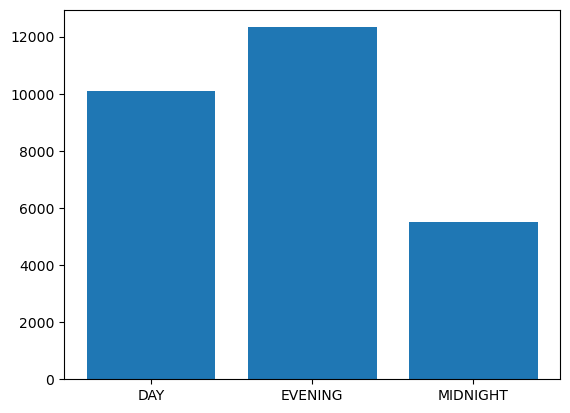

In [5]:
plt.bar(C.index, C.OBJECTID)
plt.xticks(C.index, C.SHIFT)

#### Make the graph look pretty

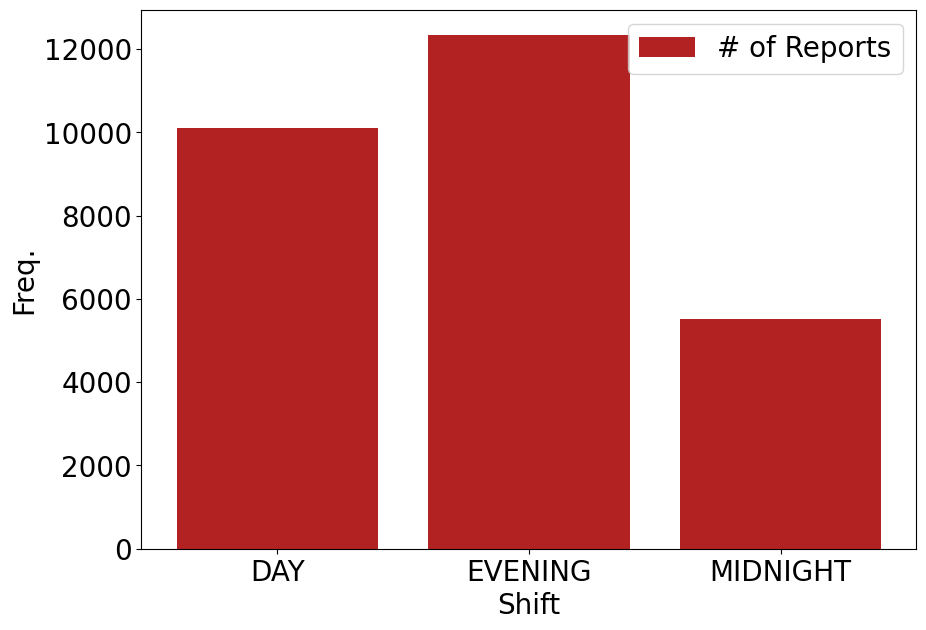

In [6]:
plt.figure(figsize=(10,7)) # Define the size of the graph

plt.bar(C.index, C.OBJECTID, label = "# of Reports", 
        color="firebrick") # Define the figure object

plt.xticks(C.index, C.SHIFT, fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel("Shift", fontsize=20)
plt.ylabel("Freq.", fontsize=20)

plt.legend(fontsize=20)

plt.savefig("barplot.png", bbox_inches="tight")

#### Try it yourself with METHOD
Create a bar chart on the METHOD column.
Named colors: https://matplotlib.org/stable/gallery/color/named_colors.html

In [14]:
M = count_bymethod = df.groupby('METHOD')['OBJECTID'].nunique().reset_index()
count_bymethod

,METHOD,OBJECTID
0,GUN,2034
1,KNIFE,641
2,OTHERS,25257


Text(0, 0.5, 'Number of Reports.')

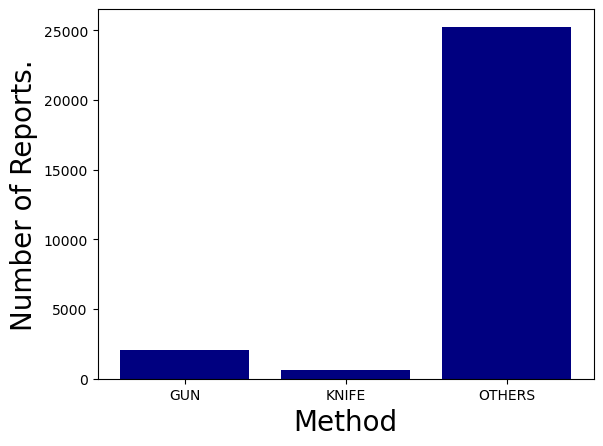

In [23]:
plt.bar(M.index, M. OBJECTID, color="navy")
plt.xticks(M.index, M.METHOD)
plt.xlabel("Method", fontsize=20)
plt.ylabel("Number of Reports.", fontsize=20)

# Histograms and Densities

(array([  38.,  150.,  292.,  514.,  867.,  777., 1260., 2624., 4521.,
        2441., 2297., 3074., 3011., 1819.,  906.,  790.,  849.,  853.,
         649.,  200.]),
 array([390147. , 391029.4, 391911.8, 392794.2, 393676.6, 394559. ,
        395441.4, 396323.8, 397206.2, 398088.6, 398971. , 399853.4,
        400735.8, 401618.2, 402500.6, 403383. , 404265.4, 405147.8,
        406030.2, 406912.6, 407795. ]),
 <BarContainer object of 20 artists>)

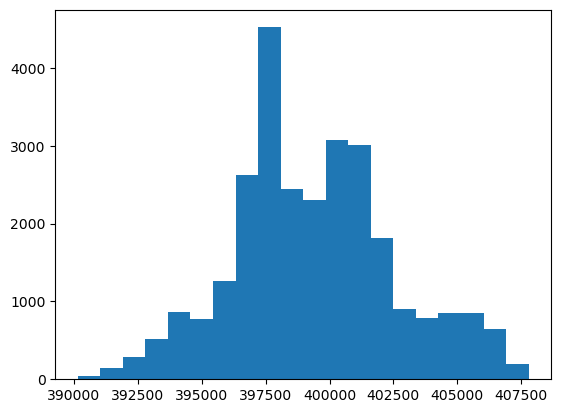

In [18]:
plt.hist( df.X, bins=20 )

Text(0, 0.5, 'Density.')

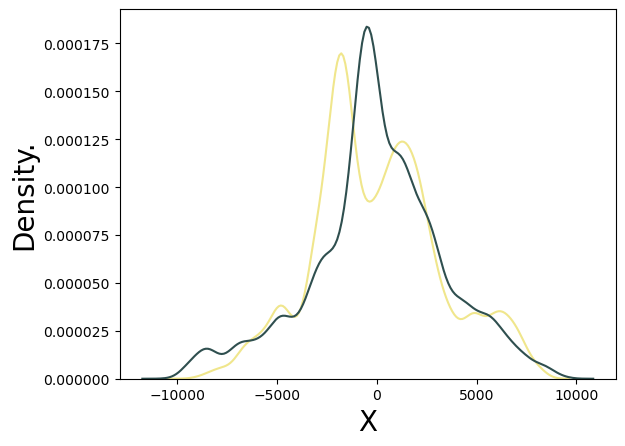

In [27]:
sns.kdeplot( df.X - df.X.mean(), color = "khaki" )
sns.kdeplot( df.Y - df.Y.mean(), color = "darkslategray" )
plt.xlabel("X", fontsize=20)
plt.ylabel("Density.", fontsize=20)

#### Your Turn: Add labels (X and Y), plot the legend, and change the color of your density
- What are the differences in distribution you observe?

In [ ]:
sns.kdeplot( df.X - df.X.mean())
sns.kdeplot( df.Y - df.Y.mean())

## Two dimensional density plots

In [ ]:
sns.kdeplot(x = df.X, y = df.Y)

#### Your turn: Plot the densities for WARDS 1, 2, and 3

- Sample 100 for each ward.
- Should take six lines of code. Hint: Do it for 1 first.

NameError: name 'plot' is not defined

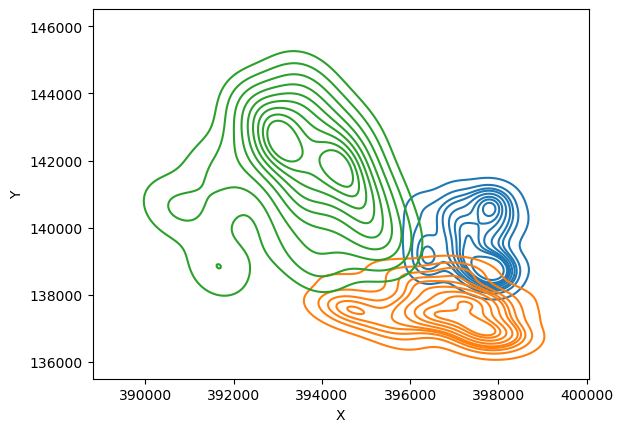

In [30]:
df1 = df[df['WARD'] == 1].sample(100)
sns.kdeplot(x = df1.X, y = df1.Y, label="Ward 1")

df2 = df[df['WARD'] == 2].sample(100)
sns.kdeplot(x = df2.X, y = df2.Y, label="Ward 2")

df3 = df[df['WARD'] == 3].sample(100)
sns.kdeplot(x = df3.X, y = df3.Y, label="Ward 3")


# Line Plots
**Goal**: bar plot where x axis is month; y axis is the count of unique crime reports (using `OBJECT_ID` as unique indicator); want line graph to be able to see trends over time in count of reported crimes

In [31]:
df['report_month'] = pd.to_datetime(df.REPORT_DAT).dt.month
df[["REPORT_DAT", "report_month"]].sample(n = 3)

,REPORT_DAT,report_month
25100,2020/11/11 13:00:39+00,11
5429,2020/11/10 05:55:37+00,11
23175,2020/04/22 14:21:24+00,4


In [32]:
### Group by month and find unique reports; same syntax as above

C = count_bymonth = df.groupby('report_month')['OBJECTID'].nunique().reset_index()
C

,report_month,OBJECTID
0,1,2950
1,2,2540
2,3,2202
3,4,1652
4,5,1834
5,6,2276
6,7,2134
7,8,2433
8,9,2570
9,10,2564


Text(0, 0.5, 'Number of Incidents')

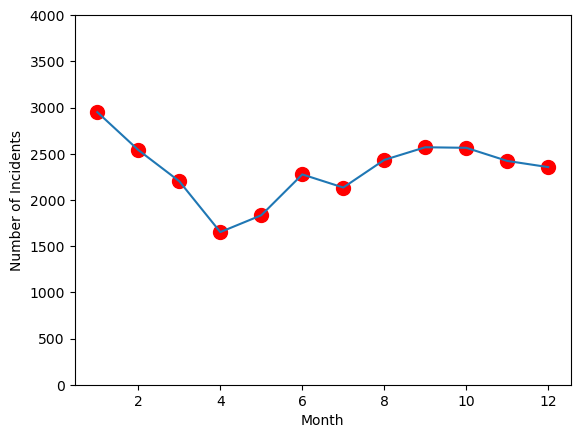

In [34]:
plt.plot(C.report_month, C.OBJECTID)

plt.scatter(C.report_month, C.OBJECTID, 
            s=100, c="red")

plt.ylim(0,4000)

plt.xlabel("Month")
plt.ylabel("Number of Incidents")

#### Your Turn: Now add the appropriate x and y labels following the same logic as the bar graph

# Read on if you have experience with R & ggplot (and prefer it)
This is here for a quick reference in how to use R-based ggplot in python. 
I almost only use Python, but this is personal preference.

### Other ways to create bars

In [ ]:

## one way: plot and display in notebook
(ggplot(count_byshift, aes(x = 'SHIFT', 
            y = 'OBJECTID')) + # base layer with data and x and y axis 
            geom_bar(stat = "identity", fill = "firebrick") + # telling it to expect a bar chart; identity
             # arg just means to use the y value 
            theme_classic() + # aesthetics
            xlab("Which shift?") + # custom label for x axis
            ylab("Count of crimes") + # custom label for y axis
            theme(axis_text = element_text(size = 14, color = "black"))) # make font bigger


In [ ]:

## another way: save to png- right now,
## it's writing to same path our df is stored in; 
plot_shifts = (ggplot(count_byshift, aes(x = 'SHIFT', 
            y = 'OBJECTID')) +
            geom_bar(stat = "identity", fill = "firebrick") +
            theme_classic() +
            xlab("Which shift?") +
            ylab("Count of crimes") +
            theme(axis_text = element_text(size = 14, color = "black")))
plot_shifts.save("plot_shifts.png", 
                width = 12,
                height = 8,
                verbose = False)


## what happens if we don't specify theme or color of bars? diff aesthetics
## also doesnt give us informative x and y labels (for pset please give 
## informative labels)
(ggplot(count_byshift, aes(x = 'SHIFT', 
            y = 'OBJECTID')) +
            geom_bar(stat = "identity"))

## Plot type two: line graph

In [ ]:
## group by month and find unique reports
### first, extract month from report_dat (just 
### with the noncleaned version)

dc_crim_2020['report_month'] = pd.to_datetime(dc_crim_2020.REPORT_DAT,
                                             errors = "coerce").dt.month
### double check this worked
dc_crim_2020[["REPORT_DAT", "report_month"]].sample(n = 3)

### then, group by month and find unique reports; same syntax as above
### just a diff grouping variable 
count_bymonth = pd.DataFrame(dc_crim_2020.groupby('report_month')['OBJECTID'].nunique()).reset_index()
count_bymonth


In [ ]:

### finally, plot result as line graph
### nearly identical syntax to above
### but uses month as the xaxis rather than
### police shift and geom_line()
### rather than geom_bar()
(ggplot(count_bymonth, aes(x = 'report_month', 
            y = 'OBJECTID')) +
            geom_line() +
            ylim(0, 3500) +
            xlab("Month of report\n(1 = jan; 12 = dec)") +
            ylab("Number of crime reports") +
            scale_x_continuous(breaks = np.arange(1, 13)))

## Making more complex: adding facets

What if we want to create the above but visualize separately for each ward?

Can group by two variables (see lecture slide) and add a line to facet_wrap

In [ ]:
### add ward as grouping var
count_bymonth_byw = pd.DataFrame(dc_crim_2020.groupby(['report_month',
                                                   'WARD'])['OBJECTID'].nunique()).reset_index()
count_bymonth_byw.head()
count_bymonth_byw.tail()

## make the facetting var prettier 
## by noting "Ward" before the
count_bymonth_byw['WARD_name'] = 'Ward: ' + count_bymonth_byw.WARD.astype(str)

### finally, plot result as line graph
### nearly identical syntax to above
### but uses month as the xaxis rather than
### police shift and geom_line()
### rather than geom_bar()
(ggplot(count_bymonth_byw, aes(x = 'report_month', 
            y = 'OBJECTID')) +
            geom_line(color = "red") +
            xlab("Month of report\n(1 = jan; 12 = dec)") +
            ylab("Number of crime reports") +
            facet_wrap('WARD_name', ncol = 2) + # ADDITIONAL LINE 
            scale_x_continuous(breaks = np.arange(1, 13)) +
            theme_538() # using 538 theme 
            ) 

In [ ]:
### rather than geom_bar()
(ggplot(count_bymonth_byw, aes(x = 'report_month', 
            y = 'OBJECTID', group = 'factor(WARD)', color = 'factor(WARD)')) +
            geom_line() +
            xlab("Month of report\n(1 = jan; 12 = dec)") +
            ylab("Number of crime reports") +
            scale_x_continuous(breaks = np.arange(1, 13)) +
            theme_538() + # using 538 theme +
             labs(color = "Ward") +
             ylim(0, 700)
            ) 